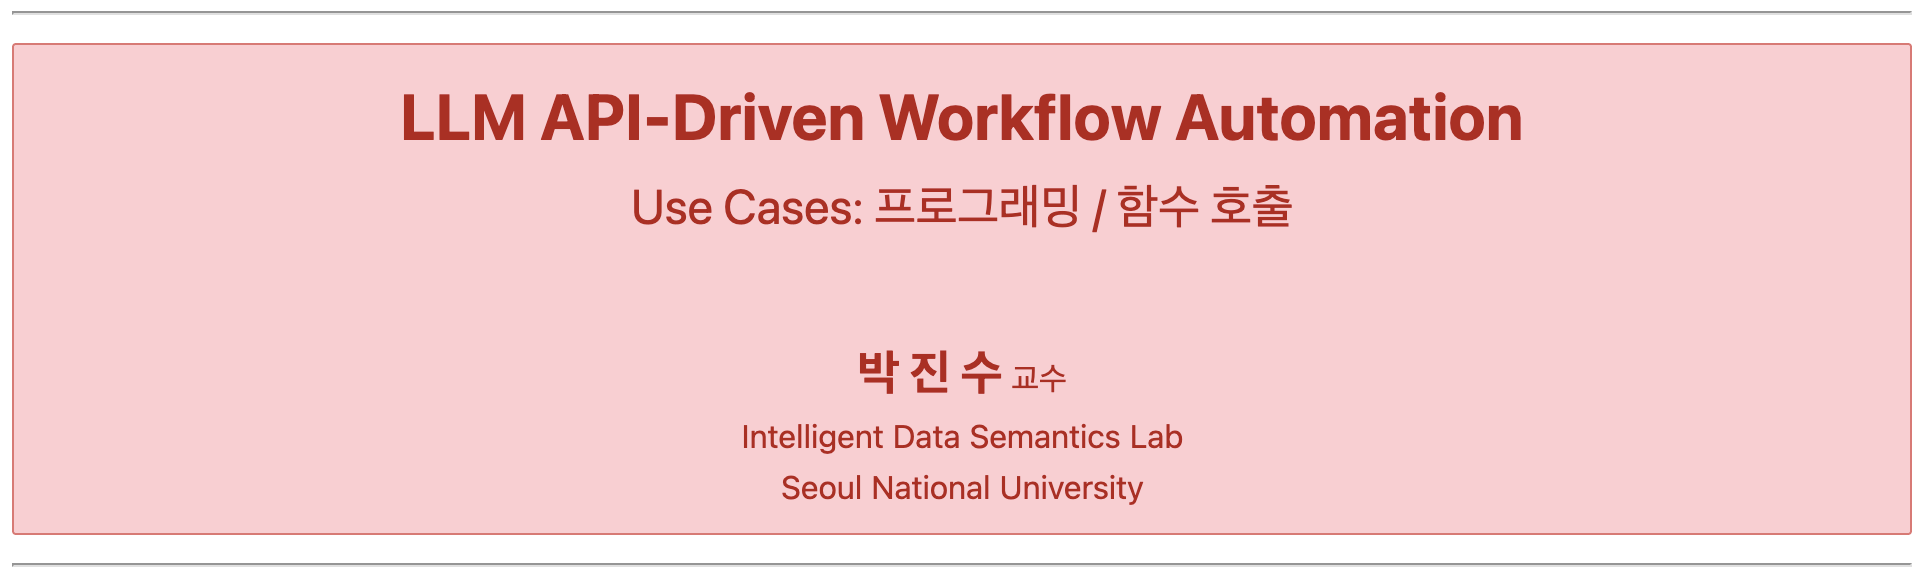

- - -    

- 본 자료는 강의를 위한 목적으로 제작되었습니다.
- 본 자료에 대한 사전 허가를 받지 않는 배포를 금지합니다.
- 본 자료를 강의나 다른 목적으로 활용하고자 하시는 경우 꼭 아래 이메일 주소로 연락주세요.
- 연락처: [jinsoo@snu.ac.kr](jinsoo@snu.ac.kr)

- - -

<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#패키지-설치-및-API-설정" data-toc-modified-id="패키지-설치-및-API-설정-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>패키지 설치 및 API 설정</a></span></li><li><span><a href="#도우미-함수-가져오기" data-toc-modified-id="도우미-함수-가져오기-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>도우미 함수 가져오기</a></span></li><li><span><a href="#자연어를-SQL로-변환" data-toc-modified-id="자연어를-SQL로-변환-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>자연어를 SQL로 변환</a></span></li><li><span><a href="#웹-페이지-제작" data-toc-modified-id="웹-페이지-제작-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>웹 페이지 제작</a></span></li><li><span><a href="#함수-호출" data-toc-modified-id="함수-호출-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>함수 호출</a></span><ul class="toc-item"><li><span><a href="#전체-흐름-정리" data-toc-modified-id="전체-흐름-정리-5.1"><span class="toc-item-num">5.1&nbsp;&nbsp;</span>전체 흐름 정리</a></span></li><li><span><a href="#Lab:-에이전트에-도구-추가하기" data-toc-modified-id="Lab:-에이전트에-도구-추가하기-5.2"><span class="toc-item-num">5.2&nbsp;&nbsp;</span>Lab: 에이전트에 도구 추가하기</a></span></li></ul></li></ul></div>

# 패키지 설치 및 API 설정

**API Key 발급 방법**
- MistralAI: https://drive.google.com/file/d/1eiRVg-hTGhN2SrJz0R7Qsn0ZS6Pw7HHd/view?usp=sharing
- Groq: https://drive.google.com/file/d/1E267hPCwahSbaKWVeCPQp2ksW8T9VsTG/view?usp=sharing
- Google Gemini: https://drive.google.com/file/d/1YLy4B4RkD6Y3HnpScpKd0trPZxKvUsXa/view?usp=sharing
- Anthropic: https://drive.google.com/file/d/1u9q-0_gCc6wmRAXNctQj8ApLRhOtYYpX/view?usp=sharing
- OpenAI: https://drive.google.com/file/d/122mEaoTYAYOPehBfChfOkNLHbZrDge3C/view?usp=sharing

In [ ]:
!python -m pip install -qU python-dotenv langchain # YOUR LLM package HERE (e.g., ollama 'langchain[ollama]' mistralai 'langchain[mistralai]' groq 'langchain[groq]' google-genai 'langchain[google-genai]' anthropic 'langchain[anthropic]' openai 'langchain[openai]')
print('--- Installation Completed', '-' * 55, '\n')

In [ ]:
# 방법 1 (API Key 명칭 수정 후 사용) - 저장한 시스템 환경 변수를 불러온다.
from dotenv import load_dotenv
load_dotenv()  # 현재 작업 디렉토리(또는 그 상위 디렉토리)에서 .env 파일을 불러온다.

In [1]:
# 방법 2 (API Key 명칭 수정 후 사용) - API Key를 입력한다.
import os, getpass
os.environ['?????_API_KEY'] = getpass.getpass('Enter Your LLM API Key: ')

Enter Your LLM API Key:  ········


In [ ]:
# 방법 3 (API Key 명칭 수정 후 사용) - (caution) API 키 노출 주의
import os
os.environ['?????_API_KEY'] = 'YOUR-LLM-API-KEY'

# 도우미 함수 가져오기


In [5]:
# --- utils.py 다운로드
!gdown 1UHksqU7wivF2308wDwEfz8Jf9-qsWyWi -O utils.py

Downloading...
From (original): https://drive.google.com/uc?id=1XVMiJglEyAagR2XgIWXc6qql54AwyFQ8
From (redirected): https://drive.google.com/uc?id=1XVMiJglEyAagR2XgIWXc6qql54AwyFQ8&confirm=t&uuid=8a95bdc2-1a6a-4db5-b670-bae62f348e8e
To: /Users/jinsoopark/Dropbox/_data/document/lecture/notebooks/generative-ai/utils.py
100%|██████████████████████████████████████| 20.0k/20.0k [00:00<00:00, 32.7MB/s]


**<u><font size='+1'>도우미 함수 사용법</font></u>**


**1. get_llm_response**(instruction, user_message, model, messages, **kwargs)
- `instruction`에 시스템 지침을, `user_message`에 사용자 입력을 전달하면 LangChain 기반으로 LLM을 호출해 응답 텍스트를 반환한다.
- `messages`에 LangChain 메시지 객체 리스트(`SystemMessage`, `HumanMessage`, `AIMessage` 등)를 직접 전달할 수도 있다. 이 경우 `instruction`과 `user_message`는 무시된다.
- `model`에 사용할 모델 ID를 전달한다 (예: `'openai:gpt-5.4-mini'`, `'google_genai:gemini-2.5-flash'`, `'anthropic:claude-sonnet-4-5-20250929'`).
    + **<font color='tomato'>이 함수의 기본 모델은 `'google_genai:gemini-3.1-flash-lite'`이다.</font>**
    + LangChain에서 사용할 수 있는 모델 이름(ID)과 형식은 공식 문서에서 확인할 수 있다.
        * https://reference.langchain.com/python/langchain/chat_models/base/init_chat_model
- `**kwargs`로 `temperature`, `max_output_tokens` 등 모델별 추가 파라미터를 전달할 수 있다.
    + 💡 참고: GPT-5를 비롯한 일부 추론 모델은 `temperature` 등 일부 파라미터를 지원하지 않는다.
- Gemini, Claude 등 일부 모델이 반환하는 블록 형태의 응답도 내부에서 자동으로 처리해 순수 텍스트만 반환한다.

**사용 예시**
```python
response = get_llm_response(instruction, user_message) # 기본값이 'google_genai:gemini-3.1-flash-lite'
response = get_llm_response(instruction, user_message, model='google_genai:gemini-3.1-flash-lite')
response = get_llm_response(instruction, user_message, model='openai:gpt-5.4-mini')
response = get_llm_response(instruction, user_message, model='anthropic:claude-haiku-4-5')
```

# 자연어를 SQL로 변환

In [ ]:
from utils import get_llm_response

instruction = '''다음 SQL 테이블들이 주어졌을 때, 
사용자의 요청에 따라 SQL 쿼리를 작성하는 것이 당신의 업무입니다.
SQL로만 변환하고 추가 설명은 하지 마세요.
그리고 답변의 시작과 끝에 SQL 코드를 표시하는 삼중 백틱(```sql)을 반드시 생략하고 SQL 코드만 출력하세요.

CREATE TABLE Orders (
    OrderID int,
    CustomerID int,
    OrderDate datetime,
    OrderTime varchar(8),
    PRIMARY KEY (OrderID)
);
    
CREATE TABLE OrderDetails (
    OrderDetailID int,
    OrderID int,
    ProductID int,
    Quantity int,
    PRIMARY KEY (OrderDetailID)
);
    
CREATE TABLE Products (
    ProductID int,
    ProductName varchar(50),
    Category varchar(50),
    UnitPrice decimal(10, 2),
    Stock int,
    PRIMARY KEY (ProductID)
);
    
CREATE TABLE Customers (
    CustomerID int,
    FirstName varchar(50),
    LastName varchar(50),
    Email varchar(100),
    Phone varchar(20),
    PRIMARY KEY (CustomerID)
);
'''

user_message = '2050년 7월 1일의 모든 주문에 대한 평균 주문 총액을 계산합니다.'

# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

# 사용자 요청을 시스템 프롬프트(테이블 스키마 포함)와 함께 LLM에 전달해 SQL 쿼리를 생성하고 출력한다.

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

# 웹 페이지 제작

In [ ]:
from IPython.display import HTML

instruction = '''당신의 업무는 사용자가 요청한 내용을 기반으로 
단일 페이지 웹사이트를 작성하는 것입니다.

웹사이트는 자바스크립트와 CSS가 내장된 HTML 파일이어야 합니다. 
HTML 문서로만 변환하고 추가 설명은 하지 마세요.
그리고 답변의 시작과 끝에 HTML 코드를 표시하는 삼중 백틱(```html)을 반드시 생략하고 HTML 코드만 출력하세요.
'''
user_message = '''현실적인 매출 데이터를 생성하여
이를 기반으로 차트(원형, 막대, 선 그래프 등 다양한 형태), 테이블, 드롭다운, 모달 등 
여러 UI 컴포넌트를 포함한 모던하고 반응형인 대시보드 웹사이트를 작성해 주세요.

당신이 생성하는 데이터는 실제 기업의 매출 데이터처럼 자연스럽고 일관성이 있어야 하며, 
데이터 간의 관계가 합리적으로 연결되도록 구성해 주세요.

사용자 인증 상태 표시, 실시간 데이터 연동(예: 간단한 가짜 API 사용)도 구현해 주시고,
색상은 깔끔한 다크 모드 톤으로 해 주세요.

각 컴포넌트에는 간략한 주석과 실제 사용 예시도 함께 써 주세요.
'''

# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

# 사용자 요청을 시스템 프롬프트와 함께 LLM에 전달해 단일 페이지 HTML 대시보드를 생성한다.

# 생성한 HTML을 파일로 저장한다.

# 생성한 HTML을 주피터 노트북에서 직접 렌더링한다.
    
# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

# 함수 호출

**LLM의 한계: LLM은 학습 데이터(training data)에서 배운 지식만 가지고 있다.** 
- 따라서, **실시간 정보**(현재 시간, 오늘 날씨, 최신 주가 등)에는 접근할 수 없다.

직접 확인해 보자.

In [5]:
# --- LLM에게 현재 시간을 물어본다.
user_message = '지금 현재 시간을 정확히 알려주세요.'

response = get_llm_response('', user_message)  # default model -> 'google_genai:gemini-flash-latest'
print(response)

현재 시간은 2024년 5월 23일 목요일 오후 4시 27분입니다.


In [9]:
# --- LLM에게 현재 시간을 물어본다.
response = get_llm_response('', user_message, model='openai:gpt-5.4-mini')
print(response)

죄송하지만, 저는 **현재 시스템의 실시간 시각을 직접 조회할 수는 없습니다**.  
대신, 사용 중인 기기에서 **현재 시간**을 바로 확인하시면 가장 정확합니다.

원하시면 제가  
- **한국 표준시(KST) 기준으로 시간 읽는 법**  
- **현재 시간이 몇 시인지 확인하는 가장 빠른 방법**  
- 또는 **지금 있는 지역 기준 시각 계산**  

을 도와드릴게요.


In [10]:
# --- 파이썬으로 실제 현재 시간을 확인한다.
from datetime import datetime

actual = datetime.now().strftime('%p %I시 %M분 %S초').replace('AM', '오전').replace('PM', '오후')
print(f'실제 현재 시간: {actual}')

실제 현재 시간: 오후 08시 47분 37초


!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!    
LLM이 못하는 일을 대신해 줄 **도구(tool)** 를 파이썬 함수로 만든다.    
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

In [11]:
# --- 도구(Tool) 정의
from datetime import datetime
from zoneinfo import ZoneInfo  

def current_date_time(timezone: str = 'Asia/Seoul') -> str:
    """주어진 시간대(timezone)의 현재 날짜와 시간을 반환한다."""
    now = datetime.now(ZoneInfo(timezone))
    return now.strftime('%Y년 %m월 %d일 %p %I시 %M분').replace('AM', '오전').replace('PM', '오후')

In [12]:
# 도구를 직접 호출해서 확인한다.
print('서울:', current_date_time('Asia/Seoul'))
print('뉴욕:', current_date_time('America/New_York'))
print('런던:', current_date_time('Europe/London'))

서울: 2026년 05월 27일 오후 08시 47분
뉴욕: 2026년 05월 27일 오전 07시 47분
런던: 2026년 05월 27일 오후 12시 47분


In [13]:
# --- Step 1: LLM에게 도구 목록을 알려주고, 도구 호출을 요청한다.

tool_instruction = '''사용 가능한 도구:
- current_date_time(timezone: str) : 주어진 시간대의 현재 날짜와 시간을 반환한다.
  + timezone 예시: 'Asia/Seoul', 'America/New_York', 'America/Los_Angeles', 'Europe/London', 'Asia/Tokyo'

규칙:
- 현재 시간이 필요하면 반드시 도구를 호출해야 합니다. 절대로 시간을 추측하지 마세요.
- 도구 호출이 필요하면 반드시 JSON 형식으로만 답하세요.
  {"tool": "current_date_time", "arguments": {"timezone": "Asia/Seoul"}}
- 도구 호출이 필요 없으면 일반 텍스트로 답하세요.
- 응답에 ```json ... ```는 포함하지 말고 출력하세요.
'''

instruction = f'당신은 친절한 도우미입니다.\n{tool_instruction}'
user_message = '지금 몇 시인가요?'

response = get_llm_response(instruction, user_message)
print('[Step 1] LLM 응답 (도구 호출 요청):')
print(response)

[Step 1] LLM 응답 (도구 호출 요청):
{"tool": "current_date_time", "arguments": {"timezone": "Asia/Seoul"}}


In [14]:
# --- Step 2: LLM의 응답을 파싱하여 실제 도구를 실행한다.
import json, re

# 사용 가능한 도구를 딕셔너리로 등록한다.
available_tools = {
    'current_date_time': current_date_time,
}

# LLM 응답에서 JSON을 추출한다.
# - LLM이 JSON 외에 텍스트를 섞어 응답할 수 있으므로 정규식으로 {...}를 추출한다.
match = re.search(r'\{[^{}]*\{[^{}]*\}[^{}]*\}', response)

try:
    tool_call = json.loads(match.group())
    tool_name = tool_call['tool']
    tool_args = tool_call['arguments']

    # 실제 도구를 실행한다.
    tool_result = available_tools[tool_name](**tool_args)
    print(f'[Step 2] 도구 실행: {tool_name}({tool_args})')
    print(f'[Step 2] 실행 결과: {tool_result}')
except (json.JSONDecodeError, KeyError, AttributeError) as err:
    tool_result = None
    print(f'JSON 파싱 실패: {err}')
    print(f'LLM 원본 응답: {response}')

[Step 2] 도구 실행: current_date_time({'timezone': 'Asia/Seoul'})
[Step 2] 실행 결과: 2026년 05월 27일 오후 08시 48분


In [15]:
# --- Step 3: 도구 실행 결과를 LLM에게 전달하여 최종 답변을 생성한다.

if tool_result:
    followup_instruction = f'''당신은 친절한 도우미입니다.
사용자의 질문에 답하기 위해 도구를 호출했고, 그 결과는 다음과 같습니다.

도구 실행 결과: {tool_result}

이 정보를 바탕으로 사용자의 질문에 자연스럽게 답하세요.
'''
    final_response = get_llm_response(followup_instruction, user_message)
    print('[Step 3] 최종 답변:')
    print(final_response)
else:
    print('[Step 3] 도구 실행 결과가 없으므로 최종 답변을 생성할 수 없습니다.')
    print('  -> Step 2에서 JSON 파싱에 실패했을 가능성이 높습니다.')
    print('  -> LLM 원본 응답을 확인하고, 프롬프트를 수정해 보십시오.')

[Step 3] 최종 답변:
지금은 2026년 5월 27일 수요일, 오후 8시 48분입니다. 즐거운 저녁 시간 보내세요!


## 전체 흐름 정리

위 3단계를 하나의 함수로 합치면 다음과 같다. 
이것이 **에이전트(Agent)의 가장 기본적인 구조**이다.
- 도구가 필요한 질문 -> 도구를 호출한 뒤 결과로 답한다.
- 도구가 필요 없는 질문 -> LLM이 바로 답한다.

In [16]:
# --- 도구 사용이 가능한 간단한 에이전트
import json, re
from datetime import datetime
from zoneinfo import ZoneInfo

# --- 1단계: 도구 등록
def current_date_time(timezone: str = 'Asia/Seoul') -> str:
    """주어진 시간대(timezone)의 현재 날짜와 시간을 반환한다."""
    now = datetime.now(ZoneInfo(timezone))
    return now.strftime('%Y년 %m월 %d일 %p %I시 %M분').replace('AM', '오전').replace('PM', '오후')

# 사용 가능한 도구를 딕셔너리로 등록한다.
available_tools = {
    'current_date_time': current_date_time,
}

TOOL_INSTRUCTION = '''사용 가능한 도구:
- current_date_time(timezone: str) : 주어진 시간대의 현재 날짜와 시간을 반환한다.
  + timezone 예시: 'Asia/Seoul', 'America/New_York', 'America/Los_Angeles', 'Europe/London', 'Asia/Tokyo'

규칙:
- 현재 시간이 필요하면 반드시 도구를 호출해야 합니다. 절대로 시간을 추측하지 마세요.
- 도구 호출이 필요하면 반드시 JSON 형식으로만 답하세요.
  {"tool": "current_date_time", "arguments": {"timezone": "Asia/Seoul"}}
- 도구 호출이 필요 없으면 일반 텍스트로 답하세요.
- 응답에 ```json ... ```는 포함하지 말고 출력하세요.
'''

# --- 2단계: 에이전트 실행 함수
def run_agent(user_message: str) -> str:
    """도구 호출이 가능한 간단한 에이전트를 실행한다."""
    # Step 1: LLM에게 도구 호출 여부를 판단하게 한다.
    INSTRUCTION = f'당신은 친절한 도우미입니다.\n{TOOL_INSTRUCTION}'
    response = get_llm_response(INSTRUCTION, user_message)

    # Step 2: 도구 호출이 필요한지 확인한다.
    # - LLM이 JSON 외에 텍스트를 섞어 응답할 수 있으므로 정규식으로 {...}를 추출한다.
    match = re.search(r'\{[^{}]*\{[^{}]*\}[^{}]*\}', response)
    if not match:
        return response  # 도구 호출이 아닌 일반 응답이면 그대로 반환한다.

    try:
        tool_call = json.loads(match.group())
        tool_name = tool_call['tool']
        tool_args = tool_call['arguments']
    except (json.JSONDecodeError, KeyError):
        return response  # 도구 호출이 아닌 일반 응답이면 그대로 반환한다.

    # Step 3: 도구를 실행한다.
    tool_result = available_tools[tool_name](**tool_args)
    print(f'  [도구 호출] {tool_name}({tool_args}) -> {tool_result}\n\n')

    # Step 4: 결과를 LLM에게 전달하여 최종 답변을 생성한다.
    followup = f'당신은 친절한 도우미입니다.\n도구 실행 결과: {tool_result}\n이 정보를 사용하여 사용자의 질문에 자연스럽게 답하세요.\n도구를 다시 호출하지 마세요.'
    return get_llm_response(followup, user_message)

In [17]:
# --- 도구가 필요한 질문
print('-' * 55)
print('질문: 지금 몇 시인가요?')
print('-' * 55)
result = run_agent('지금 몇 시인가요?')
print(result)

-------------------------------------------------------
질문: 지금 몇 시인가요?
-------------------------------------------------------
  [도구 호출] current_date_time({'timezone': 'Asia/Seoul'}) -> 2026년 05월 27일 오후 08시 49분


지금은 2026년 5월 27일 수요일 오후 8시 49분입니다. 즐거운 저녁 시간 보내세요!


In [18]:
# --- 도구가 필요 없는 질문
print('-' * 55)
print('질문: 파이썬에서 리스트와 튜플의 차이 알려주세요.')
print('-' * 55)
result = run_agent('파이썬에서 리스트와 튜플의 차이 알려주세요.')
print(result)

-------------------------------------------------------
질문: 파이썬에서 리스트와 튜플의 차이 알려주세요.
-------------------------------------------------------
파이썬에서 리스트(List)와 튜플(Tuple)은 데이터를 저장하는 방식은 비슷하지만, 결정적인 차이점이 몇 가지 있습니다.

### 1. 변경 가능성 (Mutability)
*   **리스트 (List):** **변경 가능(Mutable)**합니다. 리스트가 생성된 후에도 요소를 추가, 수정, 삭제할 수 있습니다. `[]` 대괄호를 사용합니다.
*   **튜플 (Tuple):** **변경 불가능(Immutable)**합니다. 한 번 생성되면 내부 요소를 수정하거나 삭제할 수 없습니다. `()` 소괄호를 사용합니다.

### 2. 구문과 표기법
*   **리스트:** `my_list = [1, 2, 3]`
*   **튜플:** `my_tuple = (1, 2, 3)`
    *   참고: 요소가 하나인 튜플을 만들 때는 반드시 뒤에 쉼표(`,`)를 붙여야 합니다. 예: `single_tuple = (1,)`

### 3. 성능 (Performance)
*   **튜플**이 리스트보다 메모리를 적게 차지하며, 처리 속도가 약간 더 빠릅니다. 데이터가 고정되어 있고 변할 필요가 없을 때는 리스트보다 튜플을 사용하는 것이 효율적입니다.

### 4. 사용 사례
*   **리스트:** 데이터가 계속해서 추가되거나 삭제되는 경우, 혹은 데이터의 순서나 내용이 바뀌어야 할 때 주로 사용합니다.
*   **튜플:** 데이터가 프로그램 실행 중에 절대로 바뀌지 않아야 할 때(데이터 보호), 혹은 함수의 반환값처럼 여러 값을 한 번에 묶어서 안전하게 전달하고 싶을 때 주로 사용합니다. 또한, 튜플은 변경 불가능하기 때문에 딕셔너리의 **키(Key)**로도 사용할 수 있습니다.

**요약하자면:**
"데이터를 수정해야 한다면 **

## Lab: 에이전트에 도구 추가하기

- - -
위 에이전트에 새로운 도구를 하나 더 추가해 보자.

예를 들어, 사칙연산을 수행하는 `calculate` 도구를 추가하면, LLM이 계산이 필요한 질문에 이 도구를 활용할 수 있다.

**힌트**: 
- `available_tools` 딕셔너리에 새 함수를 등록한다.
- `TOOL_INSTRUCTION`에 새 도구의 설명을 추가한다.

**실행 예시**
```
-------------------------------------------------------
질문: 지금 몇 시인가요?
-------------------------------------------------------
  [도구 호출] current_date_time({'timezone': 'Asia/Seoul'}) -> 2026년 04월 19일 오전 10시 58분


지금은 **2026년 4월 19일 오전 10시 58분**입니다.
-------------------------------------------------------
질문 2: 2의 20제곱은 얼마죠?
-------------------------------------------------------
  [도구 호출] calculate({'expression': '2 ** 20'}) -> 1048576


2의 20제곱은 **1,048,576**입니다.

-------------------------------------------------------
질문 3: 파이썬이 뭔가요?
-------------------------------------------------------
파이썬(Python)은 1991년 귀도 반 로섬(Guido van Rossum)이 발표한 프로그래밍 언어로, 다음과 같은 특징을 가지고 있습니다.

1. **읽기 쉽고 간결함**: 문법이 인간의 언어(영어)와 유사하여 배우기 쉽고, 코드의 가독성이 높습니다.
2. **인터프리터 언어**: 컴파일 과정 없이 코드를 한 줄씩 실행하여 결과를 바로 확인할 수 있습니다.
3. **방대한 라이브러리**: 데이터 분석, 인공지능(AI), 웹 개발, 자동화 등 다양한 분야에서 사용할 수 있는 도구(라이브러리)가 매우 풍부합니다.
4. **다양한 활용도**: 구글, 넷플릭스, 인스타그램 등 세계적인 기업들이 서비스 개발에 사용하고 있으며, 특히 최근에는 딥러닝과 머신러닝 분야에서 표준 언어로 자리 잡았습니다.

입문자가 배우기에 가장 추천되는 언어 중 하나입니다.

```

- - -

In [ ]:
# YOUR CODE HERE

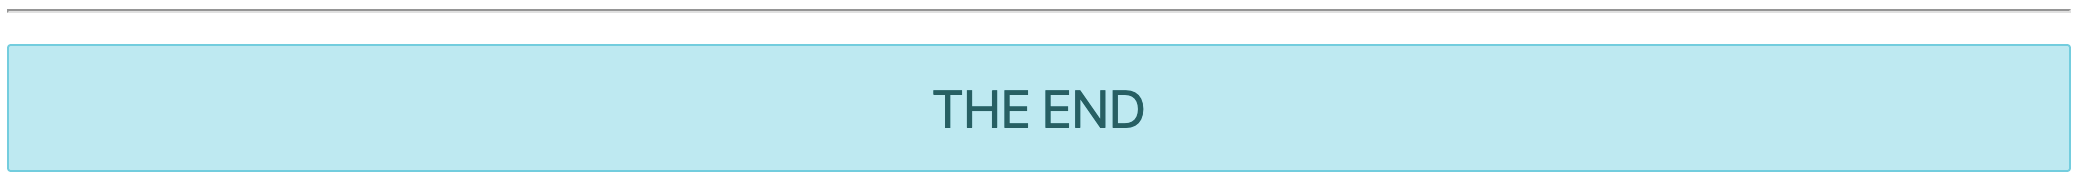